In [7]:
from google.colab import files
uploaded = files.upload()

Saving image.png to image (1).png


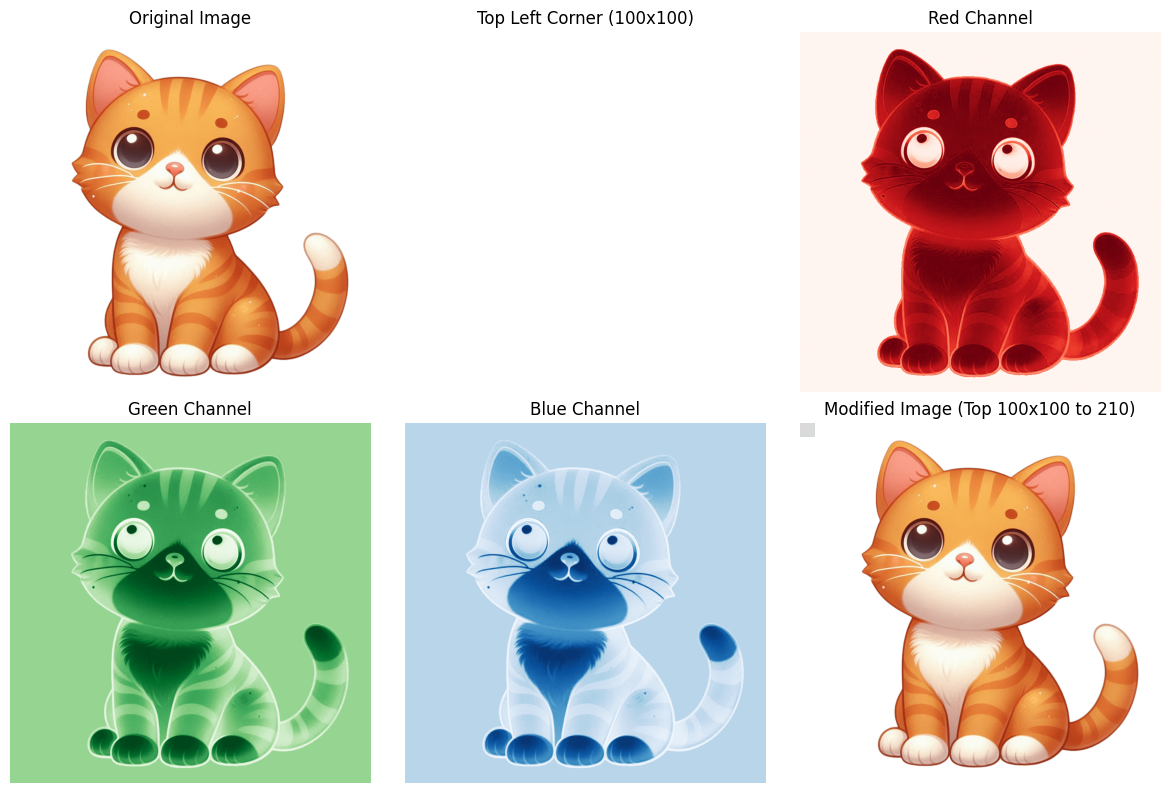

In [3]:
# 2 Getting Started with Image Processing with Python.
# Introduction to Python Imaging Library(PIL)
# 2.1 Exercise - 1:

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("image.png")   # use your image name
img_np = np.array(img)

# Extract top-left 100x100
top_left = img_np[0:100, 0:100]

# RGB channels
R = img_np[:,:,0]
G = img_np[:,:,1]
B = img_np[:,:,2]

# Modify top 100x100 pixels
modified = img_np.copy()
modified[0:100,0:100] = 210

# Plot results
fig, ax = plt.subplots(2,3, figsize=(12,8))

ax[0,0].imshow(img_np)
ax[0,0].set_title("Original Image")
ax[0,0].axis("off")

ax[0,1].imshow(top_left)
ax[0,1].set_title("Top Left Corner (100x100)")
ax[0,1].axis("off")

ax[0,2].imshow(R, cmap="Reds")
ax[0,2].set_title("Red Channel")
ax[0,2].axis("off")

ax[1,0].imshow(G, cmap="Greens")
ax[1,0].set_title("Green Channel")
ax[1,0].axis("off")

ax[1,1].imshow(B, cmap="Blues")
ax[1,1].set_title("Blue Channel")
ax[1,1].axis("off")

ax[1,2].imshow(modified)
ax[1,2].set_title("Modified Image (Top 100x100 to 210)")
ax[1,2].axis("off")

plt.tight_layout()
plt.show()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


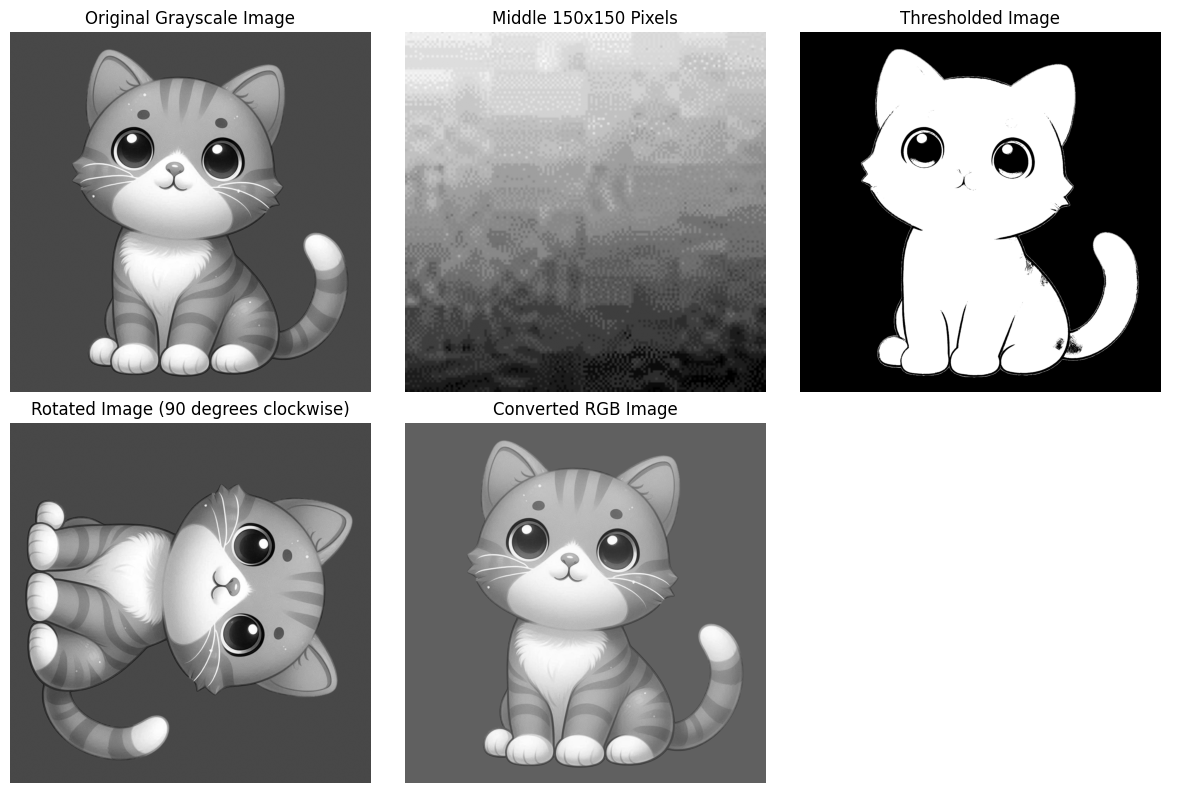

In [5]:
#2.2 Exercise - 2:

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = Image.open("image.png").convert("L")
img_np = np.array(img)

# Middle 150x150
h, w = img_np.shape
center_h, center_w = h//2, w//2
middle = img_np[center_h-75:center_h+75, center_w-75:center_w+75]

# Threshold
threshold = img_np.copy()
threshold[threshold < 100] = 0
threshold[threshold >= 100] = 255

# Rotate 90 clockwise
rotated = np.rot90(img_np, -1)

# Convert grayscale to RGB
rgb = np.stack((img_np,)*3, axis=-1)

# Plot
fig, ax = plt.subplots(2,3, figsize=(12,8))

ax[0,0].imshow(img_np, cmap="gray")
ax[0,0].set_title("Original Grayscale Image")
ax[0,0].axis("off")

ax[0,1].imshow(middle, cmap="gray")
ax[0,1].set_title("Middle 150x150 Pixels")
ax[0,1].axis("off")

ax[0,2].imshow(threshold, cmap="gray")
ax[0,2].set_title("Thresholded Image")
ax[0,2].axis("off")

ax[1,0].imshow(rotated, cmap="gray")
ax[1,0].set_title("Rotated Image (90 degrees clockwise)")
ax[1,0].axis("off")

ax[1,1].imshow(rgb)
ax[1,1].set_title("Converted RGB Image")
ax[1,1].axis("off")

ax[1,2].axis("off")

plt.tight_layout()
plt.show()

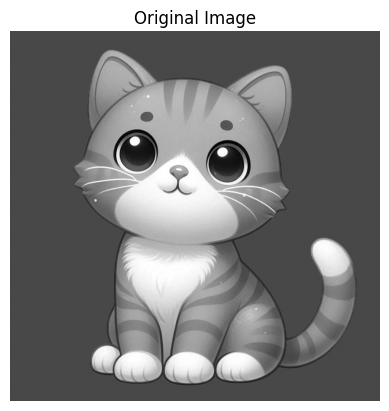

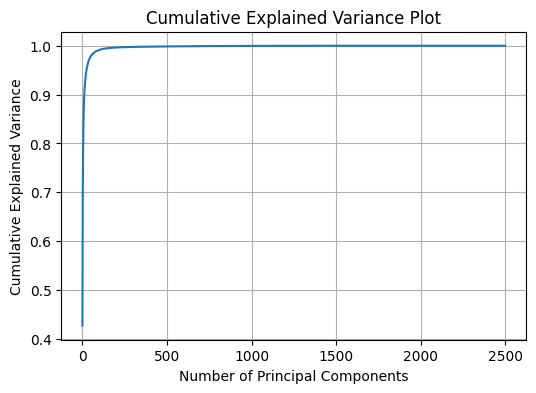

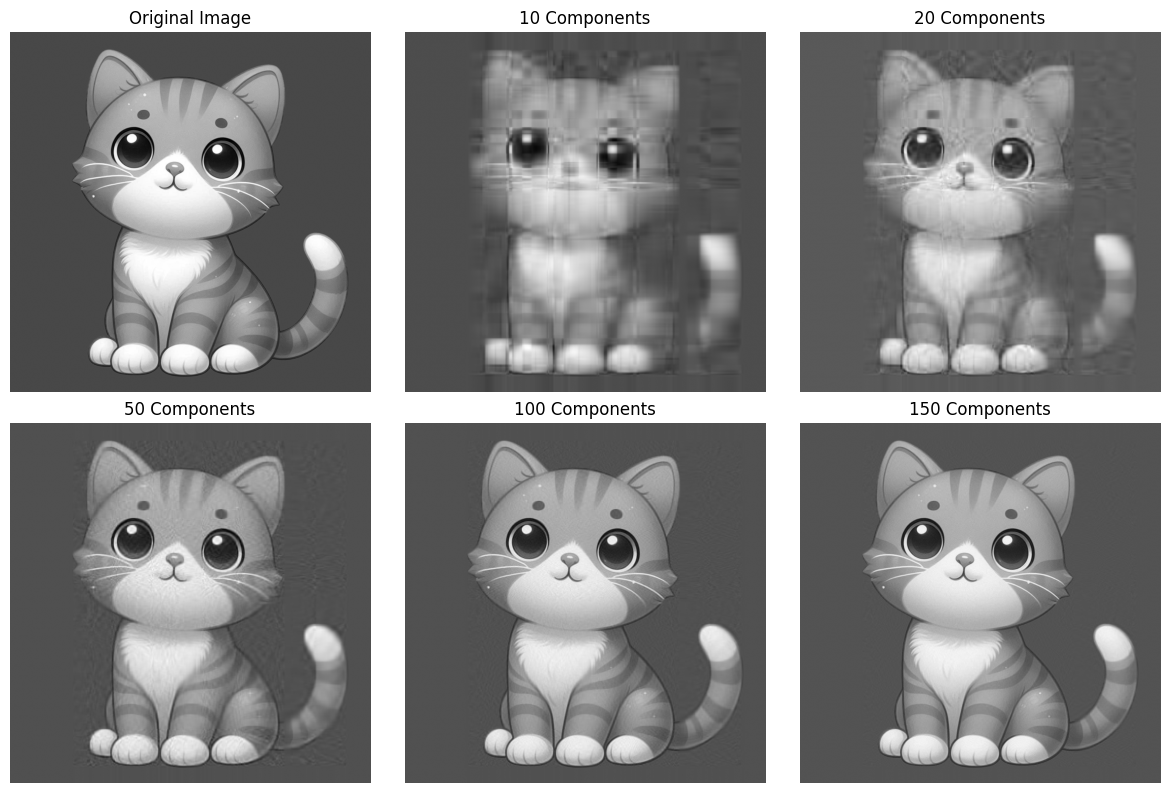

In [6]:
# 3 Image Compression and Decompression using PCA.
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load and Prepare Data

# Load image
img = Image.open("image.png").convert('L')   # convert to grayscale
img = np.array(img, dtype=float)

# Show original image
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# Center the dataset (standardize)
mean = np.mean(img, axis=0)
X_centered = img - mean

# Covariance Matrix

cov_matrix = np.cov(X_centered, rowvar=False)

# 2. Eigen Decomposition

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues in descending order
sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

# Explained Variance

explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid()
plt.show()

# 3. Reconstruction Function

def reconstruct_image(X, eigenvectors, k, mean):

    # Select top k eigenvectors
    W = eigenvectors[:, :k]

    # Project to lower dimension
    Z = np.dot(X, W)

    # Reconstruct image
    X_reconstructed = np.dot(Z, W.T) + mean

    return X_reconstructed


# Experiments with different PCs

components = [10, 20, 50, 100, 150]

reconstructed_images = []

for k in components:
    rec_img = reconstruct_image(X_centered, eigenvectors, k, mean)
    reconstructed_images.append(rec_img)


# Display Results

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

for i, k in enumerate(components):

    plt.subplot(2,3,i+2)
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.title(f"{k} Components")
    plt.axis('off')

plt.tight_layout()
plt.show()